In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
# to show the visualizations in this file itself
%matplotlib inline

In [3]:
df = pd.read_csv('weight-height.csv')

In [ ]:
df.head()

,Gender,Height,Weight
0,Male,73.847017,241.893563
1,Male,68.781904,162.310473
2,Male,74.110105,212.740856
3,Male,71.730978,220.042470
4,Male,69.881796,206.349801


In [40]:
df.isnull().sum()

,0
Height,0
Weight,0


Text(0.5, 1.0, 'Weight vs Height')

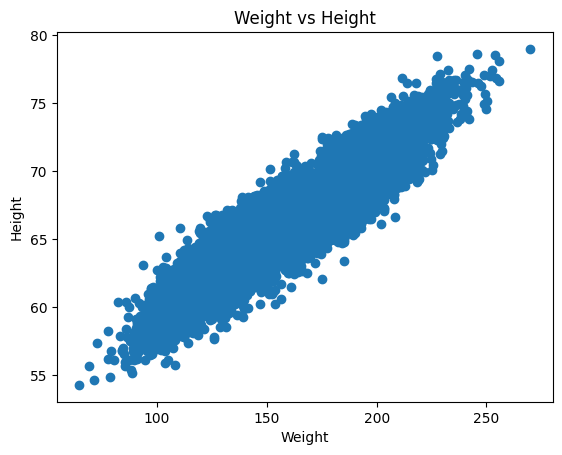

In [4]:
#Scatter Plot

plt.scatter(df['Weight'],df['Height'])
plt.xlabel('Weight')
plt.ylabel('Height')
plt.title('Weight vs Height')

In [5]:
df.drop('Gender', axis=1, inplace=True)

In [ ]:
df.head()

,Height,Weight
0,73.847017,241.893563
1,68.781904,162.310473
2,74.110105,212.740856
3,71.730978,220.042470
4,69.881796,206.349801


In [6]:
#Correlation
df.corr()

,Height,Weight
Height,1.000000,0.924756
Weight,0.924756,1.000000


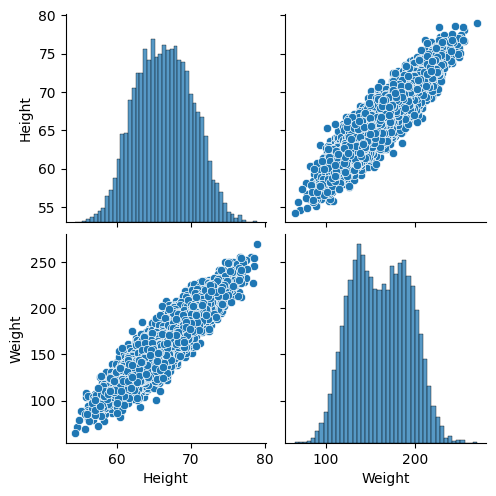

In [ ]:
#Seaborn

import seaborn as sns
sns.pairplot(df)

In [7]:
#Independent and dependent features

X = df[['Weight']]    #independent feature should be a Dataframe and not Series

Y = df['Height']       #dependent feature may be a Dataframe or Series

In [45]:
#Train Test split

from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.20, random_state=42)  #randomstate is given so that the same randomness can be maintained with sir!

In [46]:
X.shape

(10000, 1)

In [47]:
X_train.shape

(8000, 1)

In [48]:
X_test.shape

(2000, 1)

In [49]:
Y_test.shape

(2000,)

In [50]:
#Standardization
#this is needed so that Global minima can be reached faster by bigger values of independent feature
#Zscore is applied to all data points so that they al hv mean=0 & std dev.=1
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()       #z = (x- mu)/std dev
X_train = scaler.fit_transform(X_train)   #fit computes mean nd std. dev. and transform applies the z-score formula on each data point

In [51]:
X_test = scaler.transform(X_test)
#only transform is used here because we dont need to re-calculate mean nd dev. of test data, prev val is used

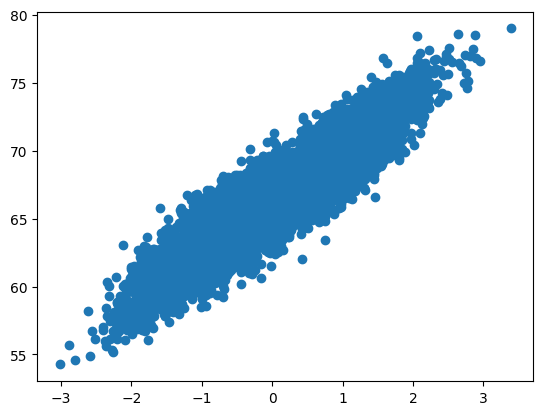

In [52]:
#Visualize scaled training data
plt.scatter(X_train, Y_train)

In [53]:
#Apply Simple Linear Regression
from sklearn.linear_model import LinearRegression
regression = LinearRegression(n_jobs=-1)    #n_jobs utilizes all the processors
regression.fit(X_train, Y_train)

LinearRegression(n_jobs=-1)

In [54]:
print("Coefficient or Slope:",regression.coef_)
print("Intercept:",regression.intercept_)

Coefficient or Slope: [3.55479288]
Intercept: 66.3596814074874


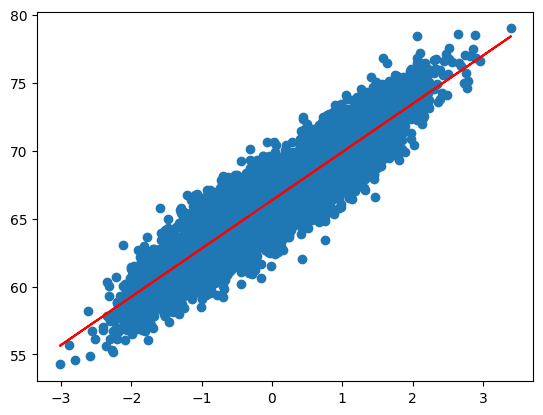

In [27]:
#Plot Training Data plot best fit line
plt.scatter(X_train, Y_train)
plt.plot(X_train,regression.predict(X_train),color='r')     #creates the best fit line with true values and predicted values[h-theta(x)] along the line

#Prediction of test Data
1. predicted ht o/p = intercept +coeff*(weights)
2. Y_pred = 66.3596 + 3.5547(X_test)

In [56]:
#Prediction for test data
Y_pred = regression.predict(X_test)

In [57]:
print(Y_pred)       #predicted output for test data
print(Y_test)       #actual o/p

[67.66759668 70.11347651 67.34604311 ... 62.34937415 69.27157847
 59.829821  ]
6252    68.687232
4684    68.829334
1731    66.398128
4742    71.929340
4521    67.042903
          ...    
6412    65.748601
8285    60.731857
7853    62.188933
1095    67.068304
6929    58.632720
Name: Height, Length: 2000, dtype: float64


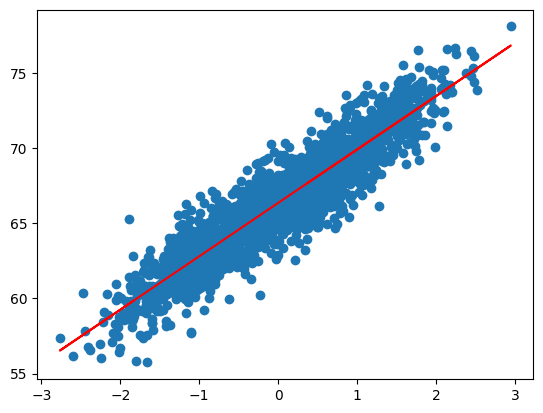

In [58]:
#Visualizing test data with its best fit line

plt.scatter(X_test, Y_test)
plt.plot(X_test,Y_pred,color='r')

In [59]:
#Performance metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error

mse = mean_squared_error(Y_test, Y_pred)
mae = mean_absolute_error(Y_test, Y_pred)
rmse = np.sqrt(mse)
print(mse)
print(mae)
print(rmse)

2.1123619485097036
1.15886563311108
1.4533966934425382


#R2-Score
R^2 = 1 - SSres/SStotal

In [60]:
from sklearn.metrics import r2_score
score = r2_score(Y_test, Y_pred)
print(score)

0.857812023087056


Adjusted R2 = 1 - [(1-R2)*(n-1)/(n-k-1)]

In [61]:
adj_r2 = 1 - ((1-score)*(len(Y_test)-1)/(len(Y_test)-X_test.shape[1]-1))
print(adj_r2)

0.8577408579334459


In [ ]:
#OLS Linear Regression

import statsmodels.api as sm
model = sm.OLS(Y_train, X_train).fit()      #model is fit using OLS library
prediction = model.predict(X_test)
print(prediction)

[ 1.3183849   3.7639285   0.99687554 ... -4.1451931   0.45415466
  0.20823876]


In [ ]:
print(model.summary())      #we see that ols gives same values as gradient descent method

                                 OLS Regression Results                                
Dep. Variable:                 Height   R-squared (uncentered):                   0.003
Model:                            OLS   Adj. R-squared (uncentered):              0.003
Method:                 Least Squares   F-statistic:                              21.48
Date:                Tue, 13 May 2025   Prob (F-statistic):                    3.63e-06
Time:                        12:08:37   Log-Likelihood:                         -42106.
No. Observations:                7500   AIC:                                  8.421e+04
Df Residuals:                    7499   BIC:                                  8.422e+04
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

In [64]:
#Prediction for new data

#scaling needs to be done so that we get correct value
#scaling needs to be done only  for selected algorithms
print("The predicted height for given weight:")
print(regression.predict(scaler.transform([[567]])))

The predicted height for given weight:
[111.36637919]


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


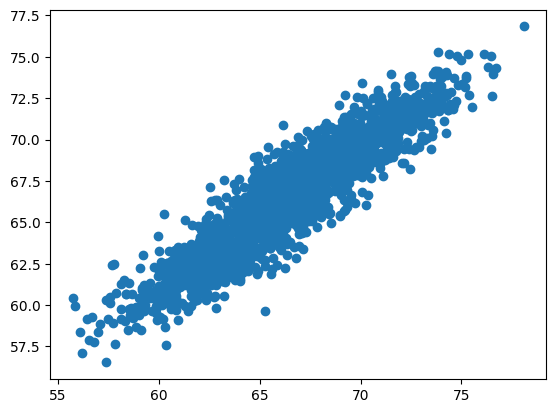

In [65]:
#Plot scatter plot for prediction of new data

plt.scatter(Y_test, Y_pred)

###Assumption 1
We see its a linear relation between actual output and predicted output , so we can say that model has perfectly worked

In [69]:
#Residuals
residuals = Y_test - Y_pred
residuals

,Height
6252,1.019636
4684,-1.284143
1731,-0.947915
4742,-0.390533
4521,-1.690374
...,...
6412,1.525611
8285,-1.039337
7853,-0.160441
1095,-2.203274


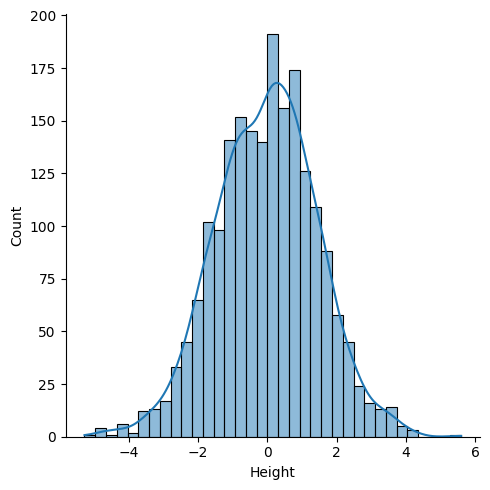

In [68]:
import seaborn as sns
sns.displot(residuals, kde=True)

###Assumption 2

It has a normal distribution so model perfect fit

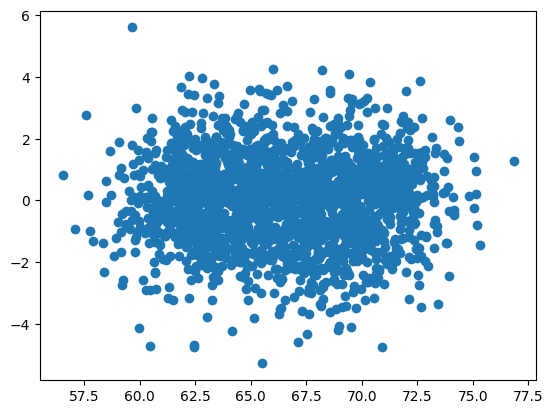

In [70]:
plt.scatter(Y_pred,residuals)

###Assumption 3

Uniform distribution of data points between predicted output and residuals shows its a good model